In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, metrics
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.naive_bayes import GaussianNB
import pickle
from os import listdir
from pathlib import Path
import random as rng
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

In [ ]:
def load_data(population, var_of_interest):
    neural_act = []
    stim_id = []
    lst = listdir('./neural_activity/' + population + var_of_interest)
    sorted_files = sorted(lst, key=lambda x: int(x.split('.')[0]))
    for f in sorted_files:
        neural_act.append(np.genfromtxt('./neural_activity/' + population + var_of_interest + '/' + f, delimiter=',', ndmin = 1))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act, dtype="object")
    stim_id = np.asarray(stim_id, dtype=float)
    return neural_act, stim_id

In [3]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

In [4]:
def build_rdm_set(size, data, stim):
    rdm_data = []
    rdm_stim = []
    for _ in range(size):
        rdm_idx = rng.randint(0, len(data)-1)
        rdm_data.append(data[rdm_idx])
        rdm_stim.append(stim[rdm_idx])
    
    return rdm_data, rdm_stim

# Amplitude

WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: Convergenc

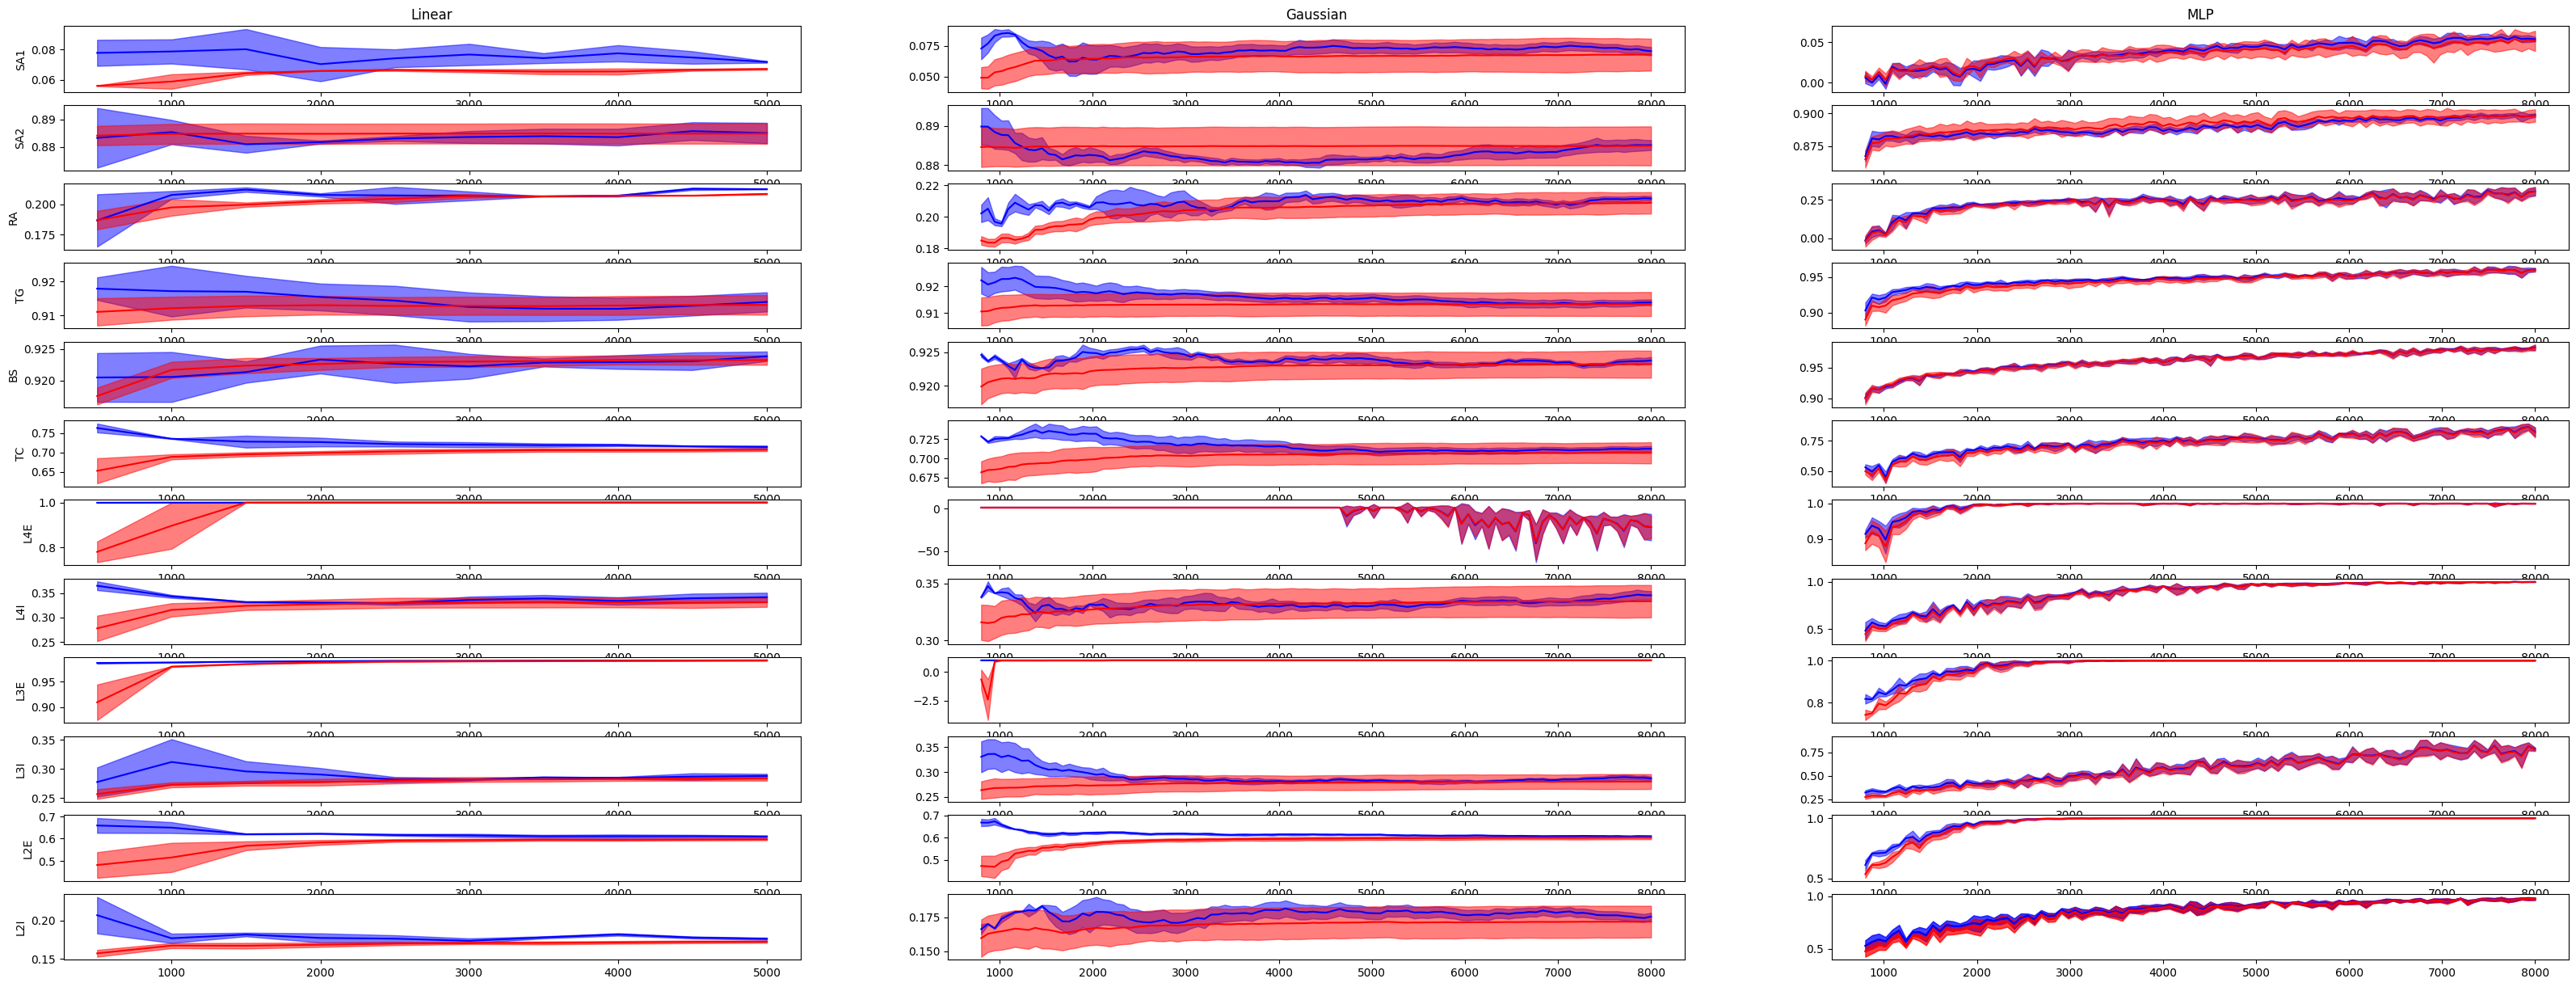

In [5]:
from sklearn.model_selection import learning_curve, ShuffleSplit
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_label = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_sizes = [24, 10, 36, 70, 70, 70, 188, 33, 158, 28, 86, 15]
Stimulus = ['0_amplitude']#, '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']

for stim in Stimulus:
    fig, axes = plt.subplots(12, 3, figsize=(40, 15))
    axes[0, 0].set_title('Linear')
    axes[0, 1].set_title('Gaussian')
    axes[0, 2].set_title('MLP')
    
    for j in range(len(Populations)):
        popsize = Populations_sizes[j]
        neural_act, stim_id = load_data(Populations[j], '/spike_id')
        spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
        for i in range(len(spike_per_neuron_per_stimulus)):
            spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)#

        axes[j, 0].set_ylabel(Populations_label[j])

        decoder_data, decoder_label = build_rdm_set(10000, spike_per_neuron_per_stimulus, stim_id)

        
        X = decoder_data
        y = decoder_label

        clf = linear_model.Ridge()
        train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, X, y, cv = 2, train_sizes=np.linspace(0.1, 1.0, 10), return_times=True)
        axes[j, 0].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
        axes[j, 0].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
        axes[j, 0].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
        axes[j, 0].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)
        
        gnb = linear_model.BayesianRidge()
        train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(gnb, X, y, cv = None, train_sizes=np.linspace(0.1, 1.0, 100), return_times=True)
        axes[j, 1].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
        axes[j, 1].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
        axes[j, 1].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
        axes[j, 1].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

        mlp = MLPRegressor()
        train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(mlp, X, y, cv = None, train_sizes=np.linspace(0.1, 1.0, 100), return_times=True)
        axes[j, 2].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
        axes[j, 2].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
        axes[j, 2].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
        axes[j, 2].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    plt.plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    plt.plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    plt.fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    plt.fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)
    plt.savefig('./Figures/Learning/' + stim + '_bis.svg')

WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: Convergenc

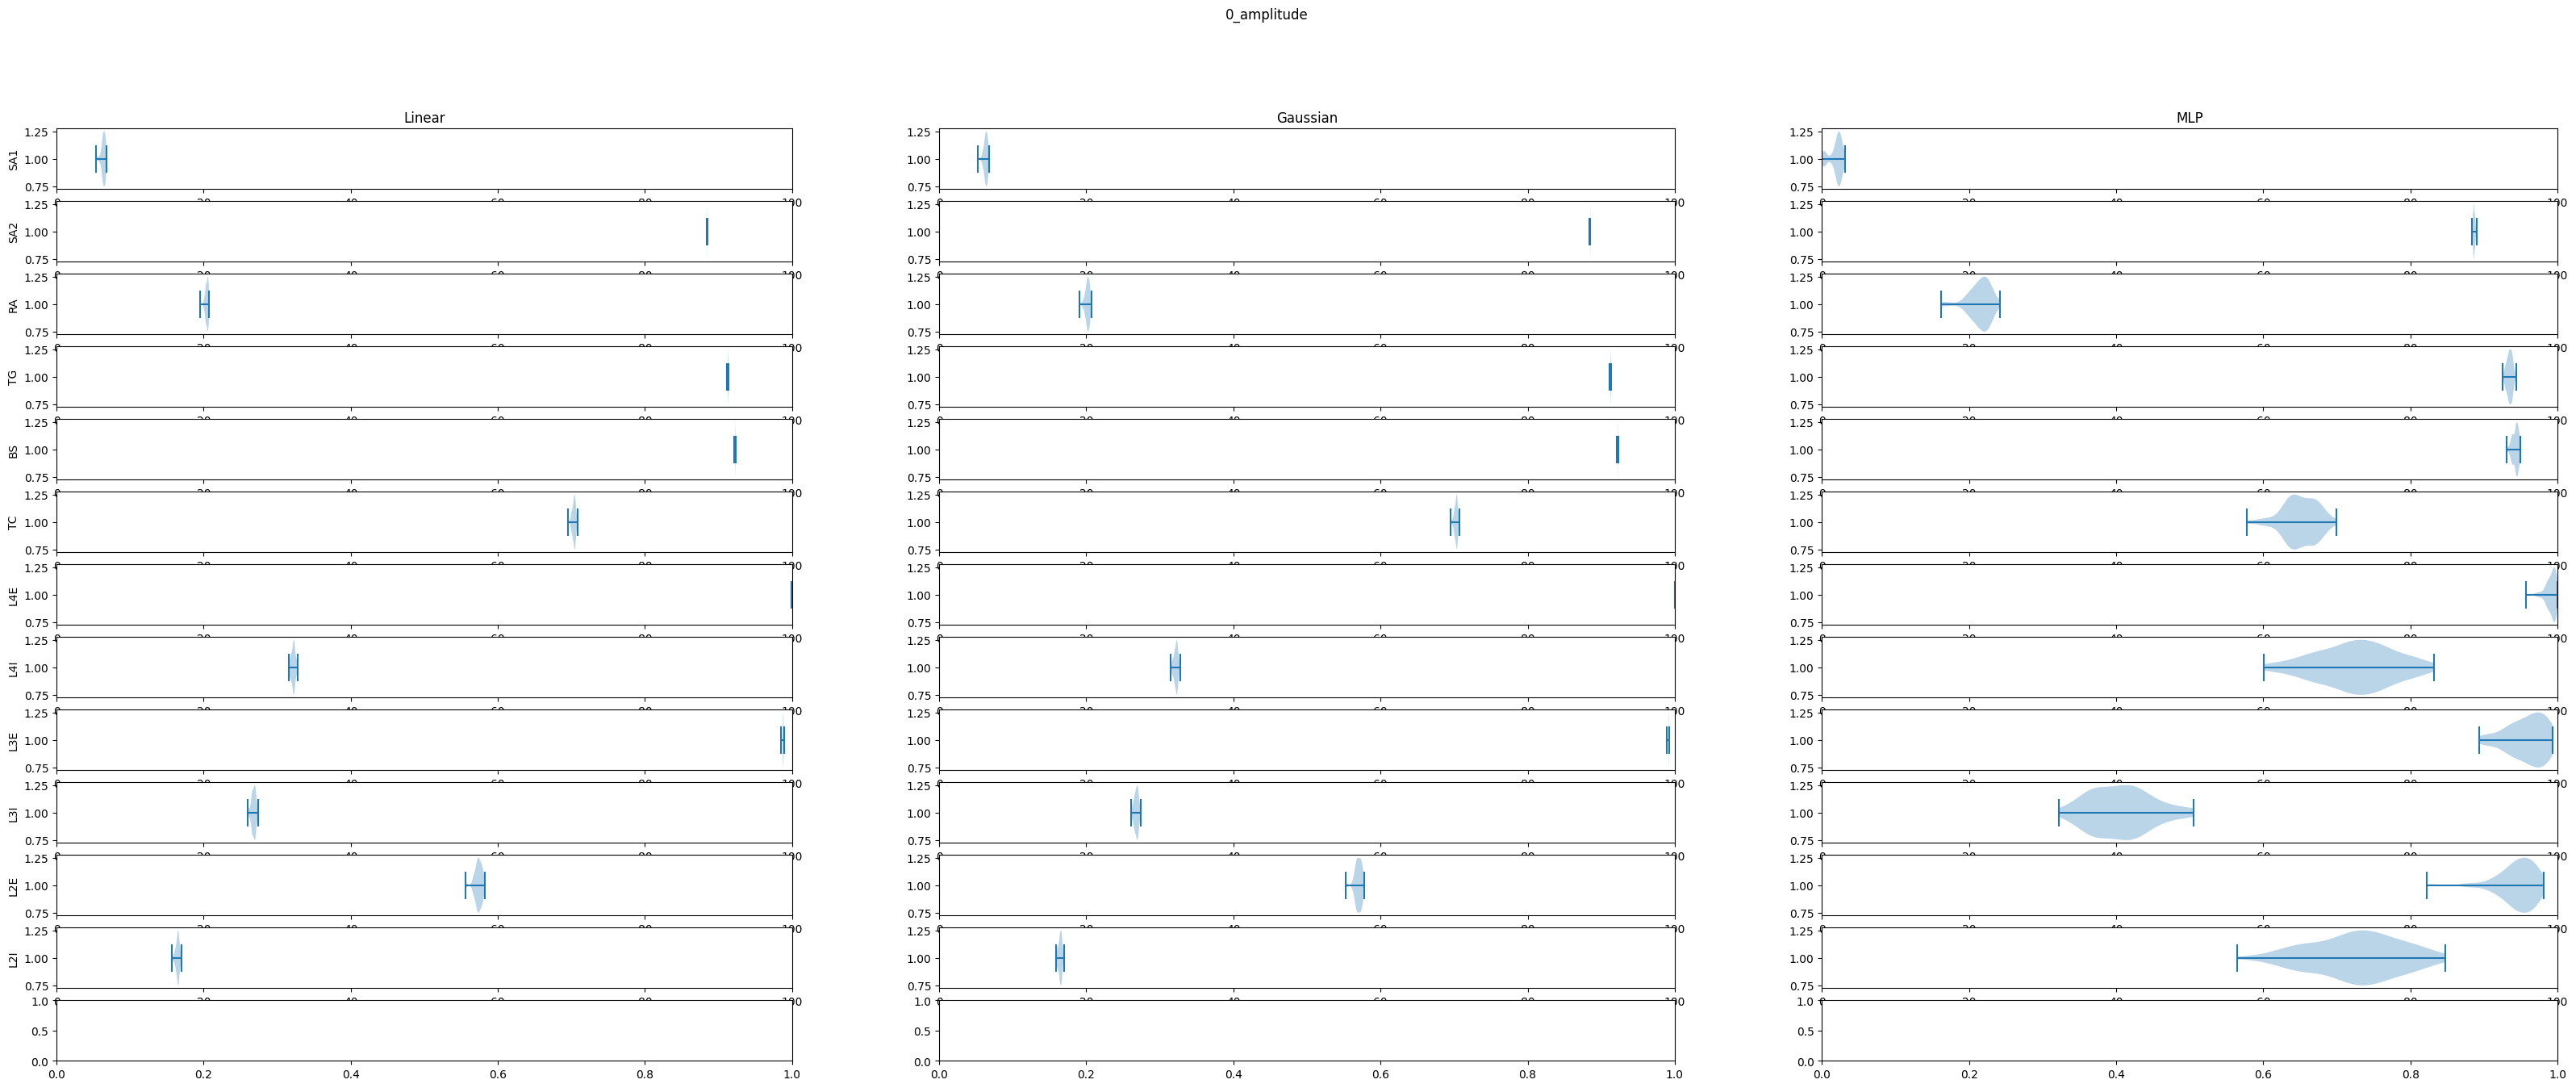

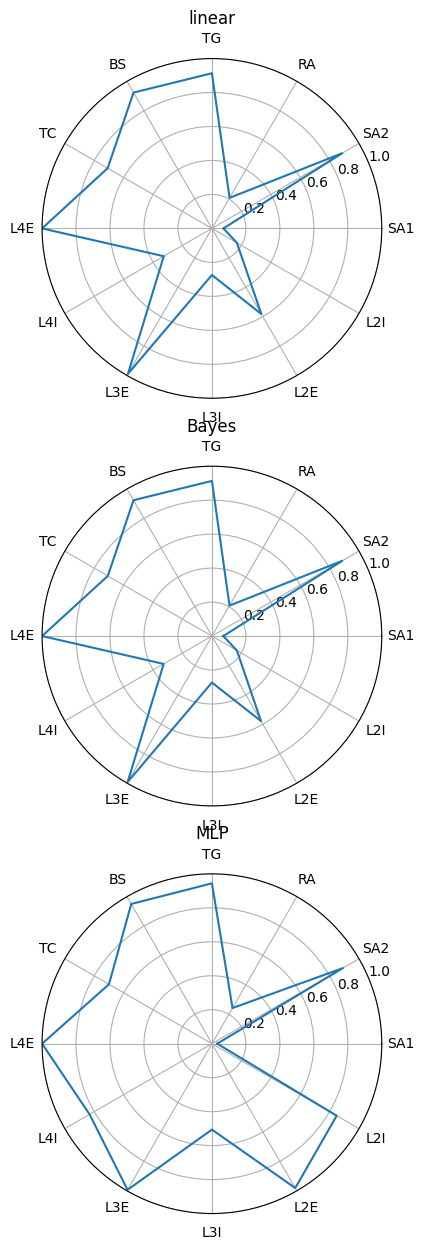

In [6]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_label = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_sizes = [24, 10, 36, 70, 70, 70, 188, 33, 158, 28, 86, 15]
Stimulus = ['0_amplitude']#, '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']

for stim in Stimulus:
    fig, axes = plt.subplots(13, 3, figsize=(40, 15))
    fig.suptitle(stim)
    axes[0, 0].set_title('Linear')
    axes[0, 1].set_title('Gaussian')
    axes[0, 2].set_title('MLP')
    max_score_per_pop_linear = []
    max_score_per_pop_bayes = []
    max_score_per_pop_mlp = []
    for j in range(len(Populations)):
        popsize = Populations_sizes[j]
        neural_act, stim_id = load_data(Populations[j], '/spike_id')
        spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
        for i in range(len(spike_per_neuron_per_stimulus)):
            spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)

        axes[j, 0].set_ylabel(Populations_label[j])

        linear_score = []
        gnb_score = []
        mlp_score = []
        for w in range(100):
            decoder_data, decoder_label = build_rdm_set(2000, spike_per_neuron_per_stimulus, stim_id)

            
            X = np.asarray(decoder_data)
            y = np.asarray(decoder_label, dtype=int)

            clf = linear_model.Ridge()
            clf.fit(X, y)

            gnb = linear_model.BayesianRidge()
            gnb.fit(X, y)

            mlp = MLPRegressor()
            mlp.fit(X, y)

            linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
            gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
            mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        max_score_per_pop_linear.append(max(linear_score))
        max_score_per_pop_bayes.append(max(gnb_score))
        max_score_per_pop_mlp.append(max(mlp_score))
        axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
        axes[j, 0].set_xlim([0, 100])
        axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
        axes[j, 1].set_xlim([0, 100])
        axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
        axes[j, 2].set_xlim([0, 100])
        plt.savefig('./Figures/Decoding/' + stim + '_full.svg')
    
    fig, ax = plt.subplots(3, 1, subplot_kw={'projection': 'polar'}, figsize=(15, 15))
    coord = np.deg2rad(np.linspace(0, 360, num=13, dtype=int))
    max_score_per_pop_linear.append(max_score_per_pop_linear[0])
    max_score_per_pop_bayes.append(max_score_per_pop_bayes[0])
    max_score_per_pop_mlp.append(max_score_per_pop_mlp[0])
    ax[0].plot(coord, max_score_per_pop_linear)
    ax[0].set_xticks(coord[:-1])
    ax[0].set_xticklabels(Populations_label)
    ax[0].set_title('linear')
    ax[0].set_ylim(0, 1)

    ax[1].plot(coord, max_score_per_pop_bayes)
    ax[1].set_xticks(coord[:-1])
    ax[1].set_xticklabels(Populations_label)
    ax[1].set_title('Bayes')
    ax[1].set_ylim(0, 1)

    ax[2].plot(coord, max_score_per_pop_mlp)
    ax[2].set_xticks(coord[:-1])
    ax[2].set_xticklabels(Populations_label)
    ax[2].set_title('MLP')
    ax[2].set_ylim(0, 1)

    plt.savefig('./Figures/Polar_decoding/' + stim + '_polar_bis.svg')

## Most informative MI (run MutualInformationCalculation_cortex first)

WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: Convergenc

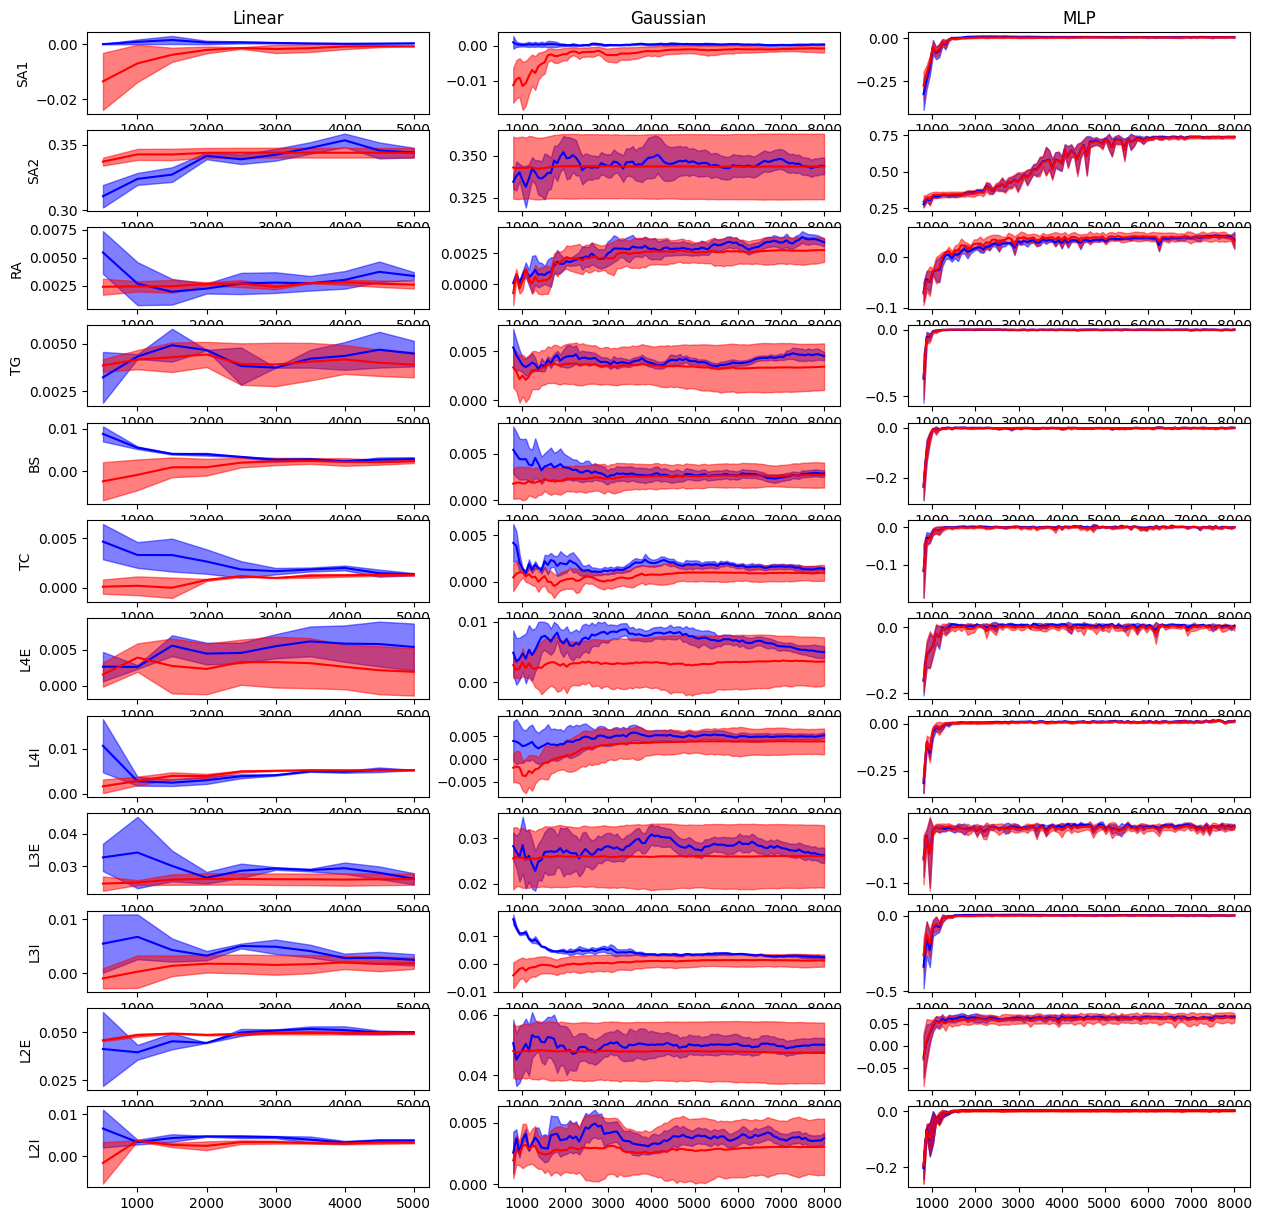

In [7]:
from sklearn.model_selection import learning_curve, ShuffleSplit
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_label = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_sizes = [24, 10, 36, 70, 70, 70, 188, 33, 158, 28, 86, 15]
Stimulus = ['0_amplitude']#, '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']

for stim in Stimulus:
    fig, axes = plt.subplots(12, 3, figsize=(15, 15))
    axes[0, 0].set_title('Linear')
    axes[0, 1].set_title('Gaussian')
    axes[0, 2].set_title('MLP')
    best_neurons = np.genfromtxt('./MI_best_neuron_per_stim/' + stim + '.csv', dtype=int)
    for j in range(len(Populations)):
        popsize = Populations_sizes[j]
        neural_act, stim_id = load_data(Populations[j], '/spike_id')
        spike_per_neuron_per_stimulus = np.zeros(len(neural_act))#, popsize))
        for i in range(len(stim_id)):
            if len(neural_act[i]) != 0:
                spike_per_neuron_per_stimulus[i] = neural_act[i][best_neurons[j]]#compute_nb_spike_per_neuron(neural_act, popsize)#[best_neurons[j]]
        spike_per_neuron_per_stimulus = spike_per_neuron_per_stimulus.reshape(-1, 1)

        axes[j, 0].set_ylabel(Populations_label[j])

        decoder_data, decoder_label = build_rdm_set(10000, spike_per_neuron_per_stimulus, stim_id)

        
        X = decoder_data
        y = decoder_label

        clf = linear_model.Ridge()
        train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, X, y, cv = 2, train_sizes=np.linspace(0.1, 1.0, 10), return_times=True)
        axes[j, 0].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
        axes[j, 0].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
        axes[j, 0].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
        axes[j, 0].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)
        
        gnb = linear_model.BayesianRidge()
        train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(gnb, X, y, cv = None, train_sizes=np.linspace(0.1, 1.0, 100), return_times=True)
        axes[j, 1].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
        axes[j, 1].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
        axes[j, 1].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
        axes[j, 1].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

        mlp = MLPRegressor()
        train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(mlp, X, y, cv = None, train_sizes=np.linspace(0.1, 1.0, 100), return_times=True)
        axes[j, 2].plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
        axes[j, 2].plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
        axes[j, 2].fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
        axes[j, 2].fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)

    plt.plot(train_sizes, np.mean(train_scores,axis=1), color='blue')
    plt.plot(train_sizes, np.mean(test_scores, axis = 1), color='red')
    plt.fill_between(train_sizes, np.mean(train_scores,axis=1) - np.std(train_scores,axis=1), np.mean(train_scores,axis=1) + np.std(train_scores,axis=1), color='blue', alpha=0.5)
    plt.fill_between(train_sizes, np.mean(test_scores,axis=1) - np.std(test_scores,axis=1), np.mean(test_scores,axis=1) + np.std(test_scores,axis=1), color='red', alpha=0.5)
    plt.savefig('./Figures/Learning_best_neuron/' + stim + '_bis.svg')

WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: Convergenc

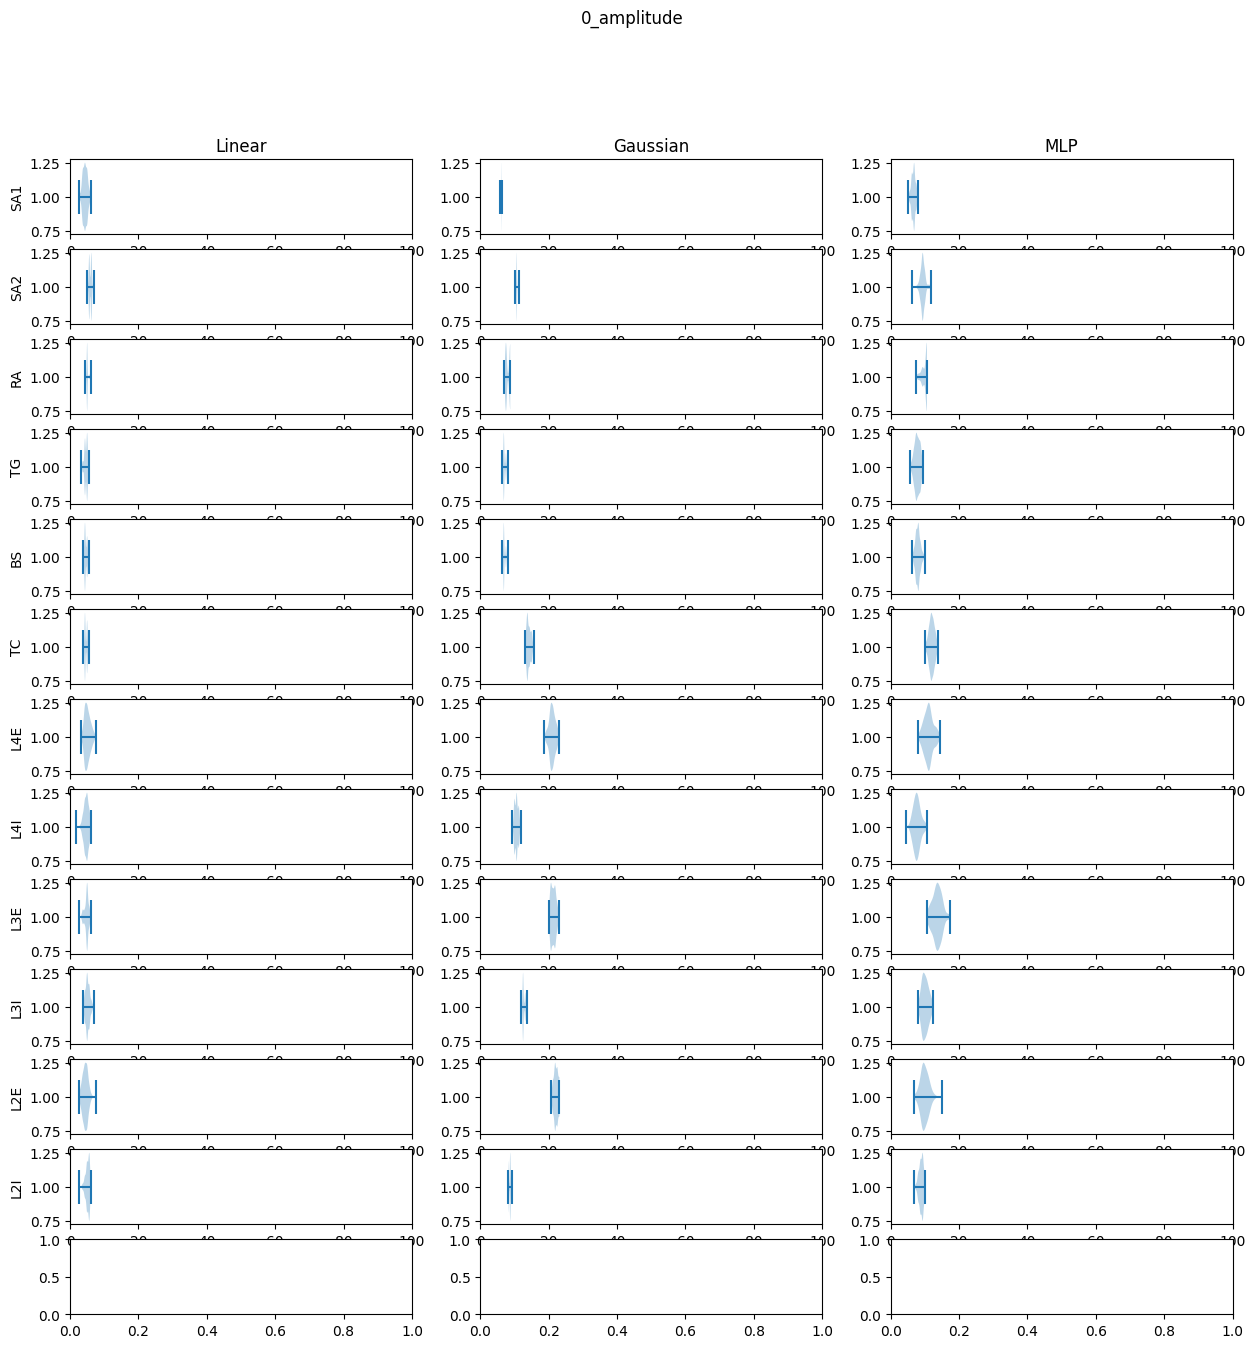

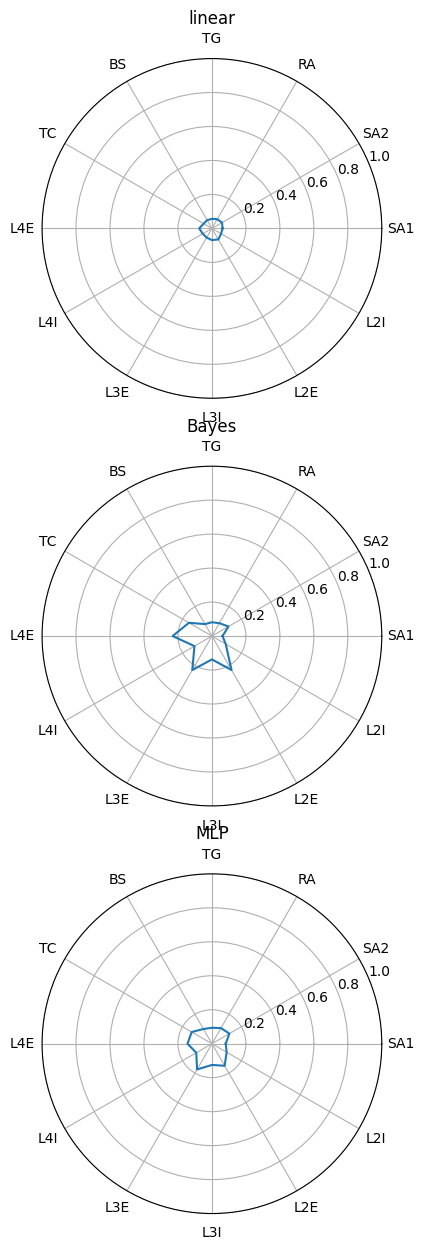

In [8]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_label = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_sizes = [24, 10, 36, 70, 70, 70, 188, 33, 158, 28, 86, 15]
Stimulus = ['0_amplitude']#, '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']

for stim in Stimulus:
    fig, axes = plt.subplots(13, 3, figsize=(15, 15))
    fig.suptitle(stim)
    axes[0, 0].set_title('Linear')
    axes[0, 1].set_title('Gaussian')
    axes[0, 2].set_title('MLP')
    max_score_per_pop_linear = []
    max_score_per_pop_bayes = []
    max_score_per_pop_mlp = []
    best_neurons = np.genfromtxt('./MI_best_neuron_per_stim/' + stim + '.csv', dtype=int)
    for j in range(len(Populations)):
        popsize = Populations_sizes[j]
        neural_act, stim_id = load_data( Populations[j], '/spike_id')
        spike_per_neuron_per_stimulus = np.zeros(len(stim_id))
        #for i in range(len(spike_per_neuron_per_stimulus)):
        for i in range(len(stim_id)):
            if len(neural_act[i]) != 0:
                spike_per_neuron_per_stimulus[i] = neural_act[i][best_neurons[j]]#compute_nb_spike_per_neuron(neural_act, popsize)#[best_neurons[j]]
        spike_per_neuron_per_stimulus = spike_per_neuron_per_stimulus.reshape(-1, 1)
        axes[j, 0].set_ylabel(Populations[j])

        linear_score = []
        gnb_score = []
        mlp_score = []
        for w in range(100):
            decoder_data, decoder_label = build_rdm_set(5000, spike_per_neuron_per_stimulus, stim_id)

            
            X = np.asarray(decoder_data)
            y = np.asarray(decoder_label, dtype=int)

            clf = linear_model.RidgeClassifier()
            clf.fit(X, y)

            gnb = GaussianNB()
            gnb.fit(X, y)

            mlp = MLPClassifier()
            mlp.fit(X, y)

            linear_score.append(clf.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
            gnb_score.append(gnb.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
            mlp_score.append(mlp.score(spike_per_neuron_per_stimulus, np.asarray(stim_id, dtype=int)))
        max_score_per_pop_linear.append(max(linear_score))
        max_score_per_pop_bayes.append(max(gnb_score))
        max_score_per_pop_mlp.append(max(mlp_score))
        axes[j, 0].violinplot(np.asarray(linear_score) * 100, vert=False)
        axes[j, 0].set_xlim([0, 100])
        axes[j, 1].violinplot(np.asarray(gnb_score) * 100, vert=False)
        axes[j, 1].set_xlim([0, 100])
        axes[j, 2].violinplot(np.asarray(mlp_score) * 100, vert=False)
        axes[j, 2].set_xlim([0, 100])
        plt.savefig('./Figures/Decoding_best/' + stim + '_full.svg')
    
    fig, ax = plt.subplots(3, 1, subplot_kw={'projection': 'polar'}, figsize=(15, 15))
    coord = np.deg2rad(np.linspace(0, 360, num=13, dtype=int))
    max_score_per_pop_linear.append(max_score_per_pop_linear[0])
    max_score_per_pop_bayes.append(max_score_per_pop_bayes[0])
    max_score_per_pop_mlp.append(max_score_per_pop_mlp[0])
    ax[0].plot(coord, max_score_per_pop_linear)
    ax[0].set_xticks(coord[:-1])
    ax[0].set_xticklabels(Populations_label)
    ax[0].set_title('linear')
    ax[0].set_ylim(0, 1)    

    ax[1].plot(coord, max_score_per_pop_bayes)
    ax[1].set_xticks(coord[:-1])
    ax[1].set_xticklabels(Populations_label)
    ax[1].set_title('Bayes')
    ax[1].set_ylim(0, 1)

    ax[2].plot(coord, max_score_per_pop_mlp)
    ax[2].set_xticks(coord[:-1])
    ax[2].set_xticklabels(Populations_label)
    ax[2].set_title('MLP')
    ax[2].set_ylim(0, 1)

    plt.savefig('./Figures/Polar_decoding_best/' + stim + '_polar_bis.svg')